In [ ]:
!pip install torch_fidelity

### Mounting Google drive to Colab and Unzipping the contents in /content/data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip /content/drive/MyDrive/Butterfly.zip -d /content/data;


Streaming output truncated to the last 5000 lines.
  inflating: /content/data/Butterfly/train/Image_6013.jpg  
  inflating: /content/data/__MACOSX/Butterfly/train/._Image_6013.jpg  
  inflating: /content/data/Butterfly/train/Image_6007.jpg  
  inflating: /content/data/__MACOSX/Butterfly/train/._Image_6007.jpg  
  inflating: /content/data/Butterfly/train/Image_1768.jpg  
  inflating: /content/data/__MACOSX/Butterfly/train/._Image_1768.jpg  
  inflating: /content/data/Butterfly/train/Image_2261.jpg  
  inflating: /content/data/__MACOSX/Butterfly/train/._Image_2261.jpg  
  inflating: /content/data/Butterfly/train/Image_4610.jpg  
  inflating: /content/data/__MACOSX/Butterfly/train/._Image_4610.jpg  
  inflating: /content/data/Butterfly/train/Image_3619.jpg  
  inflating: /content/data/__MACOSX/Butterfly/train/._Image_3619.jpg  
  inflating: /content/data/Butterfly/train/Image_4176.jpg  
  inflating: /content/data/__MACOSX/Butterfly/train/._Image_4176.jpg  
  inflating: /content/data/Butte

#### Read Labels from train_csv

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import pandas as pd
from torch.utils.data import Dataset, DataLoader,random_split
from PIL import Image
from torchvision import transforms
import os
import torchvision



In [ ]:

# Read CSV (assuming your CSV has columns: "filename","label")
train_csv = "/content/data/Butterfly/Training_set.csv"

df = pd.read_csv(train_csv)
classes = sorted(df['label'].unique())
class_to_idx = {cls: i for i, cls in enumerate(classes)}

print("Classes:", classes)
print("Mapping:", class_to_idx)


Classes: ['ADONIS', 'AFRICAN GIANT SWALLOWTAIL', 'AMERICAN SNOOT', 'AN 88', 'APPOLLO', 'ATALA', 'BANDED ORANGE HELICONIAN', 'BANDED PEACOCK', 'BECKERS WHITE', 'BLACK HAIRSTREAK', 'BLUE MORPHO', 'BLUE SPOTTED CROW', 'BROWN SIPROETA', 'CABBAGE WHITE', 'CAIRNS BIRDWING', 'CHECQUERED SKIPPER', 'CHESTNUT', 'CLEOPATRA', 'CLODIUS PARNASSIAN', 'CLOUDED SULPHUR', 'COMMON BANDED AWL', 'COMMON WOOD-NYMPH', 'COPPER TAIL', 'CRECENT', 'CRIMSON PATCH', 'DANAID EGGFLY', 'EASTERN COMA', 'EASTERN DAPPLE WHITE', 'EASTERN PINE ELFIN', 'ELBOWED PIERROT', 'GOLD BANDED', 'GREAT EGGFLY', 'GREAT JAY', 'GREEN CELLED CATTLEHEART', 'GREY HAIRSTREAK', 'INDRA SWALLOW', 'IPHICLUS SISTER', 'JULIA', 'LARGE MARBLE', 'MALACHITE', 'MANGROVE SKIPPER', 'MESTRA', 'METALMARK', 'MILBERTS TORTOISESHELL', 'MONARCH', 'MOURNING CLOAK', 'ORANGE OAKLEAF', 'ORANGE TIP', 'ORCHARD SWALLOW', 'PAINTED LADY', 'PAPER KITE', 'PEACOCK', 'PINE WHITE', 'PIPEVINE SWALLOW', 'POPINJAY', 'PURPLE HAIRSTREAK', 'PURPLISH COPPER', 'QUESTION MARK', 'R

- Necessary Imports
- Creating a class for Data Transformation
- Loading the Data from Dataset
- Transforming the images from Train Data Displaying the transformed images

In [ ]:

class CSVImageDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.data = pd.read_csv(csv_file)  # expects columns: filename,label
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name = self.data.iloc[idx, 0]   # filename
        label    = self.data.iloc[idx, 1]   # label (int or string)

        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


In [ ]:
# Preprocessing
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # Normalize between [-1, 1]
])

  # Paths
  train_csv = "/content/data/Butterfly/Training_set.csv"
  train_dir = "/content/data/Butterfly/train"


# Datasets
train_dataset = CSVImageDataset(train_csv, train_dir, transform=transform)

train_size=int(0.8*len(train_dataset))
test_size=len(train_dataset)-train_size

train_dataset,test_dataset=random_split(train_dataset,[train_size,test_size])



# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

  print("Train samples:", len(train_dataset))
  print("Test samples:", len(test_dataset))


Train samples: 5199
Test samples: 1300


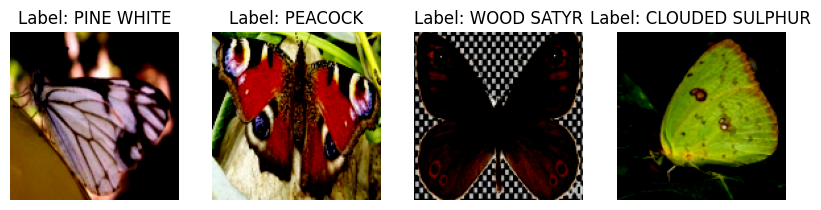

In [ ]:
# @title
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 4, figsize=(10,3))
for i in range(4):
    img = images[i].permute(1, 2,0 )  # CHW → HWC
    axes[i].imshow(img)
    axes[i].set_title(f"Label: {labels[i]}")
    axes[i].axis("off")
plt.show()


### Creating Architecture for Generator and Discriminator

In [ ]:
train_dataset[1][0].size()

torch.Size([3, 128, 128])

In [ ]:
class Generator(nn.Module):
  def __init__(self,noise_dim,img_dim):
    super(Generator,self).__init__()
    self.img_dim=img_dim
    self.model=nn.Sequential(
        nn.Linear(noise_dim,256),
        nn.BatchNorm1d(256),
        nn.ReLU(True),

        nn.Linear(256,512),
        nn.BatchNorm1d(512),
        nn.ReLU(True),

        nn.Linear(512,1024),
        nn.BatchNorm1d(1024),
        nn.ReLU(True),

        nn.Linear(1024, img_dim),
        nn.Tanh())
  def forward(self,z):
    return self.model(z)



In [ ]:
class Discriminator(nn.Module):
  def __init__(self,img_dim):
    super(Discriminator,self).__init__()
    self.img_dim=img_dim
    self.model=nn.Sequential(
        nn.Linear(img_dim,512 ),
        nn.LeakyReLU(0.2,inplace=True),
        nn.Dropout(0.3),

        nn.Linear(512,256),
        nn.LeakyReLU(0.2,inplace=True),
        nn.Dropout(0.3),

        nn.Linear(256,1))
  def forward(self,img):
    # print(img.size())
    img = img.view(img.size(0), -1)
    return self.model(img)

In [ ]:
# Suppose your dataset has N classes
num_classes = len(set(pd.read_csv("/content/data/Butterfly/Training_set.csv")['label']))

- Creating an Object of Generator
- Creating an objec of Discriminator

In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
noise_dim=100
#Calculating the dimension of Flattened Image
img_dim=torch.flatten(train_dataset[0][0]).size()[0]

gen_model=Generator(noise_dim,img_dim)
gen_model.to(device);

cuda


In [ ]:
torch.flatten(train_dataset[0][0]).size()[0]

49152

In [ ]:
discriminator_model=Discriminator(img_dim)
discriminator_model.to(device);

### Initializing Optimizer(Adam) and Loss Function(Minimax Loss or Non Saturating Loss)

In [ ]:
gen_optimizer=optim.Adam(params=gen_model.parameters(),lr=0.0002,betas=(0.5,0.99)) #Optimizer of Generator
discriminator_optimizer=optim.Adam(params=discriminator_model.parameters(),lr=0.0002,betas=(0.5,0.999)) # Optimizer for Discriminator

criterion=nn.BCEWithLogitsLoss()

In [ ]:
def show_generated_images(epoch, generator, fixed_noise):
    generator.eval()
    with torch.no_grad():
        fake_imgs = generator(fixed_noise).reshape(-1, 3, 128, 128)
        fake_imgs = fake_imgs * 0.5 + 0.5  # De-normalize

    grid = torchvision.utils.make_grid(fake_imgs, nrow=8)
    plt.figure(figsize=(8,8))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.title(f'Generated Images at Epoch {epoch}')
    plt.axis('off')
    plt.show()
    generator.train()

In [ ]:
def train_gan(train_loader, num_epochs, mode="one_one"):
    fixed_noise = torch.randn(128, noise_dim).to(device)  # For consistent visualization

    for epoch in range(num_epochs):
        for batch_idx, (real, _) in enumerate(train_loader):
            batch_size = real.size(0)
            real = real.view(batch_size, -1).to(device)

            ### Create real and fake labels
            real_labels = torch.ones(batch_size, 1).to(device)
            fake_labels = torch.zeros(batch_size, 1).to(device)

            ### ====================================
            ### 1. Train Discriminator
            ### ====================================
            # Real images
            outputs = discriminator_model(real)

            d_loss_real = criterion(outputs, real_labels)
            real_score = outputs

            # Fake images
            z = torch.randn(batch_size, noise_dim).to(device)
            fake = gen_model(z)
            outputs = discriminator_model(fake.detach())  # detach so gradients don't flow into generator
            d_loss_fake = criterion(outputs, fake_labels)
            fake_score = outputs

            # Total discriminator loss
            d_loss = d_loss_real + d_loss_fake

            discriminator_model.zero_grad()
            d_loss.backward()
            discriminator_optimizer.step()

            ### ====================================
            ### 2. Train Generator
            ### ====================================
            # Generate fake images again
            z = torch.randn(batch_size, noise_dim).to(device)
            fake = gen_model(z)
            outputs = discriminator_model(fake)

            gen_loss = criterion(outputs, real_labels)  # trick discriminator

            gen_model.zero_grad()
            gen_loss.backward()
            gen_optimizer.step()

            ### ====================================
            ### 3. Modify according to mode
            ### ====================================
            if mode == "five_gen_one_disc":
                for _ in range(4):  # already did 1 step above
                    z = torch.randn(batch_size, noise_dim).to(device)
                    fake = gen_model(z)
                    outputs = discriminator_model(fake)
                    g_loss = criterion(outputs, real_labels)

                    gen_model.zero_grad()
                    g_loss.backward()
                    gen_optimizer.step()

            if mode == "five_disc_one_gen":
                for _ in range(4):  # already did 1 step above
                    # Real
                    outputs = discriminator_model(real)
                    d_loss_real = criterion(outputs, real_labels)

                    # Fake
                    z = torch.randn(batch_size, noise_dim).to(device)
                    fake = gen_model(z)
                    outputs = discriminator_model(fake.detach())
                    d_loss_fake = criterion(outputs, fake_labels)

                    d_loss = d_loss_real + d_loss_fake

                    discriminator_model.zero_grad()
                    d_loss.backward()
                    discriminator_optimizer.step()

        if (epoch+1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], D_loss: {d_loss.item():.4f}, G_loss: {gen_loss.item():.4f}") # Changed g_loss to gen_loss
            show_generated_images(epoch+1, gen_model, fixed_noise)

Training: 1-step Gen, 1-step Disc
Epoch [10/50], D_loss: 1.3314, G_loss: 0.7731


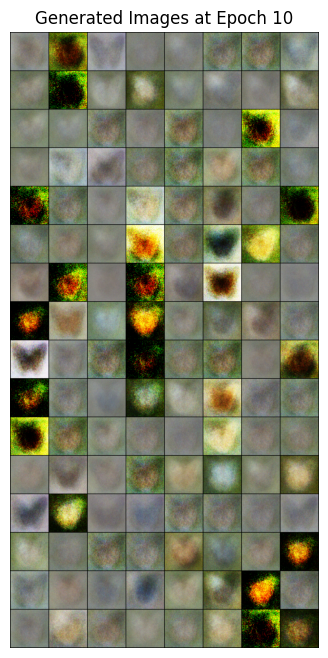

Epoch [20/50], D_loss: 1.0332, G_loss: 1.5820


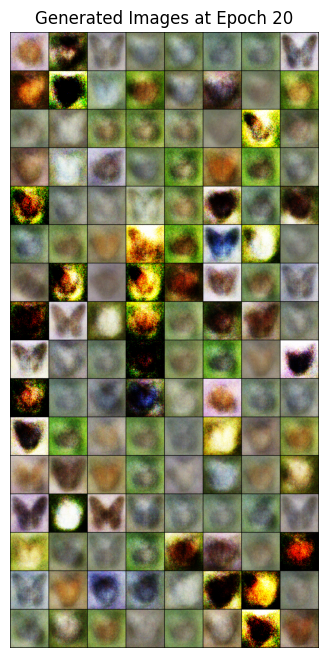

Epoch [30/50], D_loss: 1.4094, G_loss: 0.9939


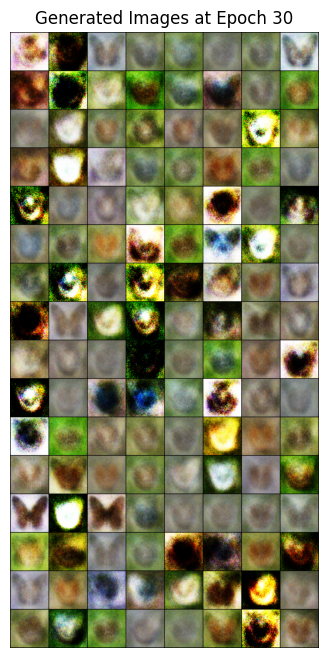

Epoch [40/50], D_loss: 1.1411, G_loss: 1.2049


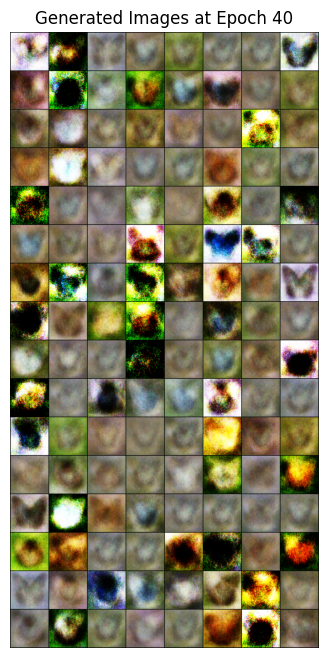

Epoch [50/50], D_loss: 1.2545, G_loss: 1.0330


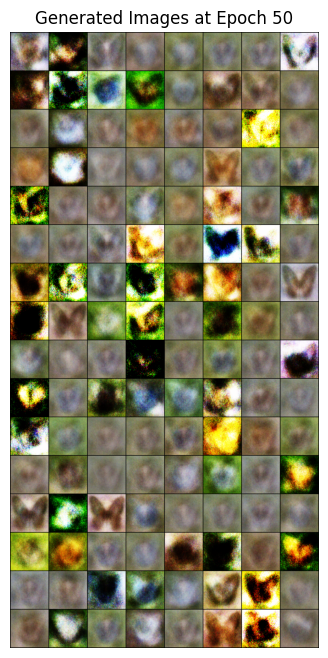

In [ ]:
  # 1. Standard: One step Generator, One step Discriminator
print("Training: 1-step Gen, 1-step Disc")
train_gan(train_loader, num_epochs=50, mode="one_one")

# # 2. 5 Generator steps, 1 Discriminator step
# print("Training: 5-step Gen, 1-step Disc")
# train_gan(train_loader, num_epochs=50, mode="five_gen_one_disc")

# # 3. 5 Discriminator steps, 1 Generator step
# print("Training: 5-step Disc, 1-step Gen")
# train_gan(train_loader, num_epochs=50, mode="five_disc_one_gen")

In [ ]:
# # 2. 5 Generator steps, 1 Discriminator step
# print("Training: 5-step Gen, 1-step Disc")
# train_gan(train_loader, num_epochs=50, mode="five_gen_one_disc")

# # 3. 5 Discriminator steps, 1 Generator step
# print("Training: 5-step Disc, 1-step Gen")
# train_gan(train_loader, num_epochs=50, mode="five_disc_one_gen")

In [ ]:

# Set generator to evaluation mode
gen_model.eval()

# 1. Set your noise dimension and output image shape
noise_dim = 100  # Change if different
img_channels = 3  # e.g., RGB images
img_size = 128    # e.g., 128 for 128x128 images

# 2. Generate a single noise sample
z = torch.randn(1, noise_dim, device=device)

# 3. Generate image
with torch.no_grad():
    fake_img = gen_model(z)  # Output: (1, C*H*W)

# 4. Reshape to image (adjust shape as per your dataset)
fake_img = fake_img.view(img_channels, img_size, img_size).cpu()

# 5. De-normalize if output is in [-1, 1] from Tanh
fake_img = fake_img * 0.5 + 0.5  # Now in [0,1]

# 6. Convert to NumPy HWC (for saving)
img_np = fake_img.permute(1, 2, 0).numpy()

# 7. Save as PNG
plt.imsave('generated_butterfly.png', img_np)

print("Image saved as 'generated_butterfly.png'")


Image saved as 'generated_butterfly.png'


In [ ]:
len(test_dataset)

1300

In [ ]:
import os

from tqdm import tqdm

import torch_fidelity

# =====================================
# CONFIGURATION
# =====================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

noise_dim = 100
img_channels = 3
img_size = 128
batch_size = 32

real_dir = "real_test"
fake_dir = "generated"
os.makedirs(real_dir, exist_ok=True)
os.makedirs(fake_dir, exist_ok=True)

# =====================================
# SAVE REAL TEST IMAGES
# =====================================
print("Saving real test images...")
real_counter = 0

for imgs, _ in tqdm(test_loader):
    imgs = imgs.cpu()
    for img in imgs:
        img = (img * 0.5 + 0.5).clamp(0, 1)  # de-normalize if dataset normalized to [-1, 1]
        img_np = img.permute(1, 2, 0).numpy()
        save_path = os.path.join(real_dir, f"real_{real_counter:04d}.png")
        plt.imsave(save_path, img_np)
        real_counter += 1

print(f"✅ Saved {real_counter} real test images in '{real_dir}/'")

# =====================================
# GENERATE FAKE IMAGES
# =====================================
gen_model.eval()
num_fake_images = real_counter
num_batches = (num_fake_images + batch_size - 1) // batch_size
fake_counter = 0

print("Generating fake images...")
with torch.no_grad():
    for _ in tqdm(range(num_batches)):
        z = torch.randn(batch_size, noise_dim, device=device)
        fake_imgs = gen_model(z)

        if fake_imgs.dim() == 2:
            fake_imgs = fake_imgs.view(-1, img_channels, img_size, img_size)

        fake_imgs = (fake_imgs * 0.5 + 0.5).clamp(0, 1).cpu()

        for img in fake_imgs:
            if fake_counter >= num_fake_images:
                break
            img_np = img.permute(1, 2, 0).numpy()
            save_path = os.path.join(fake_dir, f"fake_{fake_counter:04d}.png")
            plt.imsave(save_path, img_np)
            fake_counter += 1

print(f"✅ Saved {fake_counter} fake images in '{fake_dir}/'")




Saving real test images...


100%|██████████| 41/41 [00:14<00:00,  2.78it/s]


✅ Saved 1300 real test images in 'real_test/'
Generating fake images...


100%|██████████| 41/41 [00:08<00:00,  4.61it/s]

✅ Saved 1300 fake images in 'generated/'


In [ ]:
print("Computing FID and KID metrics...")
metrics = torch_fidelity.calculate_metrics(
    input1=real_dir,
    input2=fake_dir,
    fid=True,
    kid=True,
    metrics=["fid", "kid"],
    device=device
)


In [ ]:
print(f"FID: {metrics['frechet_inception_distance']:.4f}")
print(f"KID: {metrics['kernel_inception_distance_mean']:.6f}")   # For mean KID value



FID: 330.3205
KID: 0.341367
